# Thousands of CBF-QPs in parallel — a unicycle safety filter

A **control-barrier-function quadratic program (CBF-QP)** is the standard *safety filter* in
robot control: given a nominal control, it returns the nearest control that provably keeps the
robot inside a safe set. One robot, one timestep, one small QP.

cuPIQP solves **thousands of them at once**. This mirrors training a reinforcement-learning
policy across many parallel environments: we run thousands of *independent* unicycle environments
-- they do not interact -- each with a robot navigating to a goal around an obstacle. Every
environment runs its own CBF-QP safety filter, and the whole batch is solved in a *single* GPU
call per timestep.

**Acknowledgement:** this unicycle model and CBF formulation is adapted from Taekyung Kim's [**safe_control**](https://github.com/tkkim-robot/safe_control).

## Problem formulation

**Unicycle kinematics.** Each robot has states $x=(p_x,p_y,\theta)$ containing its position $p=(p_x,p_y)$ and
heading angle $\theta$ and is driven by the inputs $u=(v,\omega)$, where $v$ is the linear
velocity and $\omega$ the angular velocity:

$$
\dot p_x = v\cos\theta, \qquad
\dot p_y = v\sin\theta, \qquad
\dot\theta = \omega ,
$$

equivalently $\dot x = g(x)\,u$ with the control-input matrix
$g(x)=\begin{bmatrix}\cos\theta & 0\\ \sin\theta & 0\\ 0 & 1\end{bmatrix}$ and no drift term.

**Barrier.** The robot must avoid a circular obstacle centered at $p_o$. Writing $r_{\text{obs}}$
and $r_{\text{rob}}$ for the obstacle and robot radii, their centers must stay at least
$d_{\min}=r_{\text{obs}}+r_{\text{rob}}$ apart. The safe set is $\{x : h(x)\ge 0\}$, where
safe_control's heading-aware *smoothed* control barrier function $h$ is

$$
h(x) = \lVert p-p_o\rVert^2 \;-\; \beta\,d_{\min}^2 \;-\; \sigma(s),
\qquad
\sigma(s)=k_2\,\frac{e^{\,k_1-s}-1}{e^{\,k_1-s}+1},
$$

so that $h\ge 0$ means "safe". Here $\beta\gtrsim 1$ is a safety-margin multiplier on $d_{\min}^2$,
and $\sigma(s)$ is the heading-aware smoothing term shaped by the constants $k_1,k_2$. The offsets
$s$ and $t$ resolve the direction to the obstacle along and across the current heading:

$$
s = (p-p_o)^\top\!\begin{bmatrix}\cos\theta\\[2pt] \sin\theta\end{bmatrix}
\quad\text{(along heading)}, \qquad
t = (p-p_o)^\top\!\begin{bmatrix}-\sin\theta\\[2pt] \cos\theta\end{bmatrix}
\quad\text{(across heading)} .
$$

The $\theta$-dependence of $\sigma$ is what lets $\omega$ enter the safety constraint; without it
the unicycle barrier would only constrain $v$.

**CBF condition.** To stay in the safe set we enforce $\dot h(x,u) + \alpha\,h(x)\ge 0$, where
$\alpha>0$ is a class-$\mathcal{K}$ gain setting how fast $h$ is allowed to decrease. Because
$\dot h = \nabla h(x)^\top g(x)\,u$ is *linear in* $u$, we collect its coefficient into the row
vector

$$
a(x) \;=\; \nabla h(x)^\top g(x) \;=\; \big[\,2s-\sigma'(s),\ \; -\sigma'(s)\,t\,\big] ,
\qquad \sigma'(s)=\tfrac{d\sigma}{ds},
$$

so the safety condition becomes the single linear inequality $\,a(x)\,u + \alpha\,h(x)\ge 0$.

**CBF-QP (one per robot).** Given a nominal command $u_{\text{ref}}$ -- the controller's desired
$(v,\omega)$, defined in the next cell -- return the control closest to it that stays safe and
respects the actuator limits $v_{\max},\omega_{\max}$:

$$
\begin{aligned}
\min_{u=(v,\omega)} \quad & \tfrac12\,\lVert u - u_{\text{ref}} \rVert_2^2 \\
\text{subject to} \quad
  & a(x)\,u + \alpha\,h(x) \;\ge\; 0, \\
  & -v_{\max} \;\le\; v \;\le\; v_{\max}, \\
  & -\omega_{\max} \;\le\; \omega \;\le\; \omega_{\max} .
\end{aligned}
$$

Each QP has 2 variables, 1 inequality, and box bounds -- tiny on its own. We solve many of them at once.

In [11]:
import time
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

from cupiqp import DenseSolver, Status

float_dtype = cp.float32              # float32: faster, and plenty for a safety filter

# --- scenario ---
B            = 4096                   # unicycles solved in parallel
dt, T        = 0.03, 450              # timestep, horizon
v_max, w_max = 1.5, 3.0               # control limits |v|, |omega|
k_w          = 3.0                    # heading gain of the nominal controller
alpha        = 6.0                    # class-K gain in the CBF:  hdot + alpha*h >= 0

obs          = cp.array([0.0, 0.0], dtype=float_dtype)   # circular obstacle at the origin
r_obs, r_rob = 1.0, 0.1
d_min        = r_obs + r_rob          # required center-to-center distance
beta, k1, k2 = 1.01, 0.5, 1.8         # barrier margin + smoothing (from safe_control)
goal         = cp.array([4.0, 0.0], dtype=float_dtype)
d_infl, k_rep, k_tan = 2.2, 0.0, 1.2  # nominal steering field near the obstacle

## Where the CBF-QP sits in the control loop

The safety filter is a thin layer between whatever produces the nominal command -- a hand-tuned
controller, an MPC, or a learned policy -- and the robot. Each control cycle the command flows
through three stages:

	nominal controller  ->  CBF-QP safety filter  ->  safe control

- **Nominal controller** produces the desired command $u_\text{ref}$ (here, go-to-goal; in general an
  MPC or a learned policy). It is not guaranteed to keep the robot safe.
- **CBF-QP safety filter** reads the current state $x$ and returns the control closest to $u_\text{ref}$
  that still satisfies the safety constraint and the actuator limits -- it minimizes
  $\frac{1}{2} \|u - u_\text{ref}\|^2$ subject to the CBF condition and the box bounds on $u$.
- **Safe control** $u^*$ is the filter's output, the command actually applied to the robot.

That single QP -- solved once per environment, every control cycle -- is what cuPIQP runs in
parallel across all the environments at once.

In [12]:
def barrier_and_grad(X):
    """Smoothed relative-degree-1 CBF for the unicycle.

    Returns h and a in the CBF constraint: a * u + alpha * h >= 0.
    """
    x, y, th = X[:, 0], X[:, 1], X[:, 2]
    ct, st = cp.cos(th), cp.sin(th)
    dx, dy = x - obs[0], y - obs[1]
    s = dx * ct + dy * st                        # distance projected onto heading
    t = dy * ct - dx * st                        # perpendicular projection
    E = cp.exp(k1 - s)
    sig  = k2 * (E - 1.0) / (E + 1.0)            # heading-aware smoothing sigma(s)
    dsig = -2.0 * k2 * E / (E + 1.0) ** 2        # d sigma / d s
    h = dx * dx + dy * dy - beta * d_min ** 2 - sig
    a = cp.stack([2.0 * s - dsig, -dsig * t], axis=1)
    return h, a

def nominal_policy(X):
    """Go-to-goal with a tangential steering bias near the obstacle -> [v, omega], (B, 2)."""
    x, y, th = X[:, 0], X[:, 1], X[:, 2]
    tgx, tgy = goal[0] - x, goal[1] - y
    gn = cp.sqrt(tgx * tgx + tgy * tgy) + 1e-6
    ax, ay = tgx / gn, tgy / gn                 # unit vector toward the goal
    ox, oy = x - obs[0], y - obs[1]
    d = cp.sqrt(ox * ox + oy * oy) + 1e-6
    rx, ry = ox / d, oy / d                     # radial, away from the obstacle
    px, py = -ry, rx                            # tangential
    sgn = cp.sign(px * ax + py * ay)
    sgn = cp.where(sgn == 0, 1.0, sgn)
    px, py = sgn * px, sgn * py                 # pick the side that makes progress to the goal
    w = cp.clip((d_infl - d) / (d_infl - d_min), 0.0, 1.0)
    vx = ax + w * (k_rep * rx + k_tan * px)
    vy = ay + w * (k_rep * ry + k_tan * py)
    vn = cp.sqrt(vx * vx + vy * vy) + 1e-6
    th_des = cp.arctan2(vy, vx)
    e = cp.arctan2(cp.sin(th_des - th), cp.cos(th_des - th))
    speed = cp.clip(v_max * cp.minimum(vn, 1.0), 0.0, v_max) * cp.clip(cp.cos(e), 0.0, 1.0)
    return cp.stack([speed, cp.clip(k_w * e, -w_max, w_max)], axis=1)

def step(X, u):
    """Euler-integrate the unicycle kinematics, in place."""
    th = X[:, 2]
    X[:, 0] += dt * u[:, 0] * cp.cos(th)
    X[:, 1] += dt * u[:, 0] * cp.sin(th)
    X[:, 2] += dt * u[:, 1]

def initial_states(B, seed=0):
    rng = cp.random.RandomState(seed)
    X = cp.empty((B, 3), dtype=float_dtype)
    X[:, 0] = rng.uniform(-4.5, -3.5, B)        # start in a band on the left
    X[:, 1] = rng.uniform(-2.8,  2.8, B)
    X[:, 2] = rng.uniform(-0.3,  0.3, B)        # roughly facing +x
    return X

## Simulate many parallel environments with the CBF-QP filter

In [13]:
X = initial_states(B)
n = 2

# fixed parts of the batched QP
P   = cp.broadcast_to(cp.eye(n, dtype=float_dtype), (B, n, n)).copy()        # 1/2||u - u_ref||^2 -> P = I
x_l = cp.broadcast_to(cp.array([-v_max, -w_max], dtype=float_dtype), (B, n)).copy()
x_u = cp.broadcast_to(cp.array([ v_max,  w_max], dtype=float_dtype), (B, n)).copy()

# set up once with the first step's data
u_ref = nominal_policy(X)
h, a = barrier_and_grad(X)
solver = DenseSolver(dtype="float32" if float_dtype is cp.float32 else "float64")
solver.setup(
    P=P, c=-u_ref,
    G=a.reshape(B, 1, n), h_l=(-alpha * h).reshape(B, 1), h_u=None,
    x_l=x_l, x_u=x_u
    )
solver.solve()

traj = cp.empty((T + 1, B, 2), dtype=float_dtype)
traj[0] = X[:, :2]
min_clear = cp.full(B, cp.inf, dtype=float_dtype)

# diagnostics: barrier over time, and when / where the filter intervenes
h_hist        = cp.empty((T + 1, B), dtype=float_dtype)
active_hist   = cp.zeros((T, B), dtype=cp.bool_)   # nominal would breach the CBF -> filter acts
adjust_hist   = cp.empty((T, B), dtype=float_dtype)  # magnitude of the filter correction ||u - u_ref||

cp.cuda.Stream.null.synchronize()
t0 = time.time()
for k in range(T):
    u_ref = nominal_policy(X)
    h, a = barrier_and_grad(X)
    h_hist[k] = h
    # same structure every step -> update(), not setup()
    solver.update(c=-u_ref, G=a.reshape(B, 1, n), h_l=(-alpha * h).reshape(B, 1))
    solver.solve()
    u = solver.result.x
    # CBF value at the nominal control; < 0 means the nominal would breach it and the filter must act
    active_hist[k]   = (a * u_ref).sum(axis=1) + alpha * h < 0.0
    adjust_hist[k]   = cp.sqrt(((u - u_ref) ** 2).sum(axis=1))
    step(X, u)                                     # apply the filtered, safe control
    traj[k + 1] = X[:, :2]
    min_clear = cp.minimum(min_clear, cp.sqrt(X[:, 0] ** 2 + X[:, 1] ** 2) - d_min)
cp.cuda.Stream.null.synchronize()
elapsed = time.time() - t0
h_last, _ = barrier_and_grad(X)
h_hist[T] = h_last

n_solved = sum(1 for q in solver.result.info.status if q == Status.CUPIQP_SOLVED)
reached = float(cp.mean((cp.sqrt((X[:, 0] - goal[0]) ** 2 + (X[:, 1] - goal[1]) ** 2) < 0.5)))
print(f"{B} unicycles x {T} steps  ->  {B * T:,} CBF-QPs solved in {elapsed:.2f} s "
      f"({B * T / elapsed / 1e3:.0f}k solves/s)")
print(f"QPs converged at the final step      : {n_solved}/{B}")
print(f"min clearance over all robots & time : {float(cp.min(min_clear)):+.3f}  (>= 0 means safe)")
print(f"reached the goal                     : {reached * 100:.0f}%")

4096 unicycles x 450 steps  ->  1,843,200 CBF-QPs solved in 5.13 s (359k solves/s)
QPs converged at the final step      : 4096/4096
min clearance over all robots & time : +0.205  (>= 0 means safe)
reached the goal                     : 100%


Every trajectory bends around the safety boundary (grey ring) and still reaches the goal.
Each line is one of the $B$ robots; only a sample is drawn.

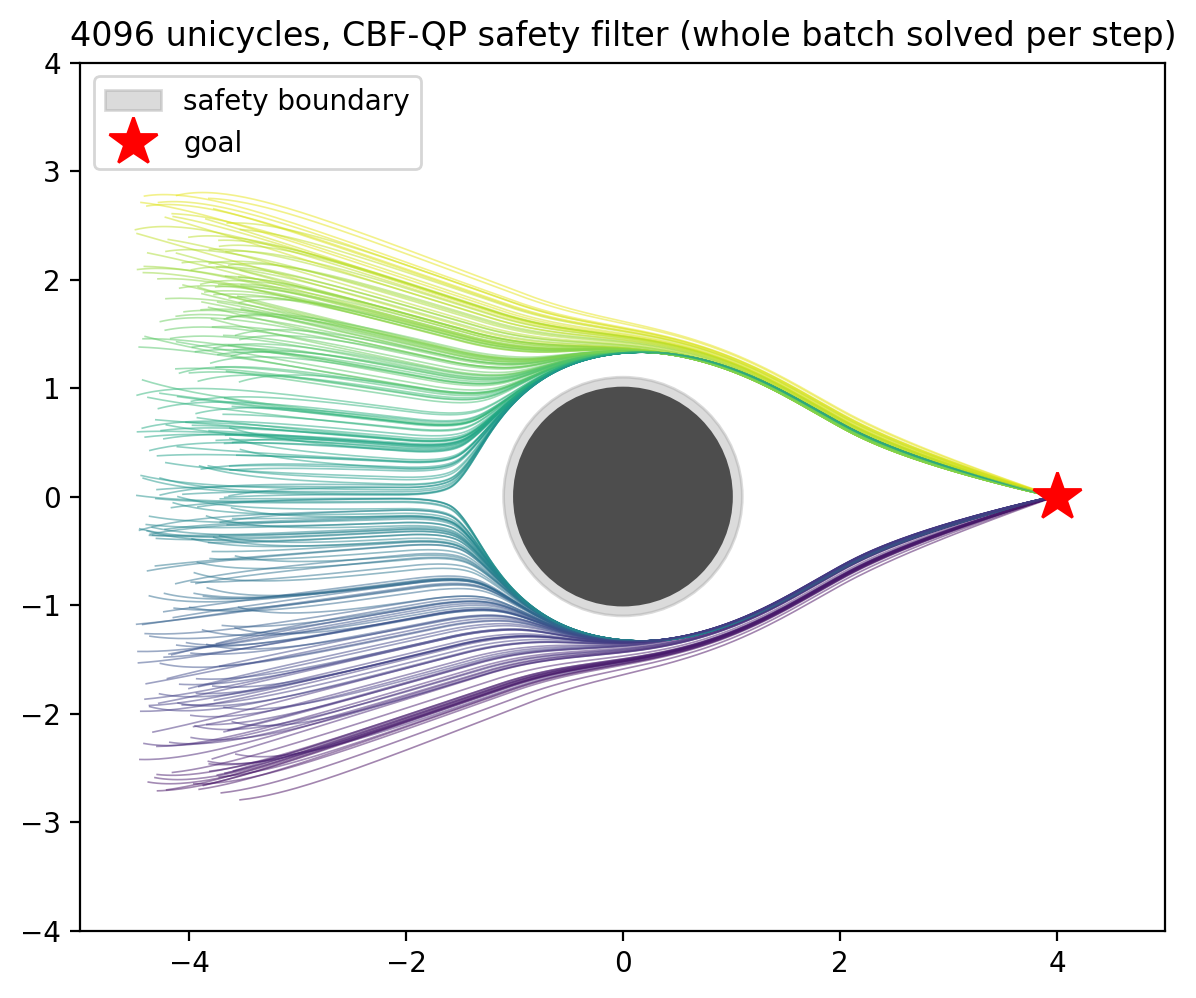

In [14]:
traj_h = traj.get()                                # (T+1, B, 2) -> host
y0 = traj_h[0, :, 1]
idx = np.linspace(0, B - 1, 250).astype(int)        # draw a sample of trajectories

fig, ax = plt.subplots(figsize=(7, 6))
ax.add_patch(plt.Circle((0, 0), d_min, color="0.6", alpha=0.35, label="safety boundary"))
ax.add_patch(plt.Circle((0, 0), r_obs, color="0.3"))
for i in idx:
    ax.plot(traj_h[:, i, 0], traj_h[:, i, 1], lw=0.6, alpha=0.5,
            color=plt.cm.viridis((y0[i] + 3) / 6))
ax.plot(float(goal[0]), float(goal[1]), "r*", ms=18, label="goal")
ax.set_aspect("equal")
ax.set_xlim(-5, 5)
ax.set_ylim(-4, 4)
ax.set_title(f"{B} unicycles, CBF-QP safety filter (whole batch solved per step)")
ax.legend(loc="upper left")
plt.show()

## Does the filter actually do anything?

Run the **same nominal policy without the CBF-QP**. The nominal steering is decent but not
*certified* — a sizeable fraction of robots clip the safety boundary. The CBF-QP turns the
guarantee into a hard one, for all robots, at once.

In [15]:
X = initial_states(B)
lo = cp.array([-v_max, -w_max], dtype=float_dtype); hi = cp.array([v_max, w_max], dtype=float_dtype)
traj_no = cp.empty((T + 1, B, 2), dtype=float_dtype); traj_no[0] = X[:, :2]
min_clear_no = cp.full(B, cp.inf, dtype=float_dtype)
for k in range(T):
    step(X, cp.clip(nominal_policy(X), lo, hi))            # nominal control, no safety filter
    traj_no[k + 1] = X[:, :2]
    min_clear_no = cp.minimum(min_clear_no, cp.sqrt(X[:, 0] ** 2 + X[:, 1] ** 2) - d_min)

viol_no  = int(cp.sum((min_clear_no < 0).astype(cp.int32)))
viol_cbf = int(cp.sum((min_clear    < 0).astype(cp.int32)))
print(f"robots that breached the safety boundary")
print(f"  nominal only : {viol_no:5d} / {B}  ({viol_no / B * 100:.0f}%)")
print(f"  with CBF-QP  : {viol_cbf:5d} / {B}")

robots that breached the safety boundary
  nominal only :  1614 / 4096  (39%)
  with CBF-QP  :     0 / 4096


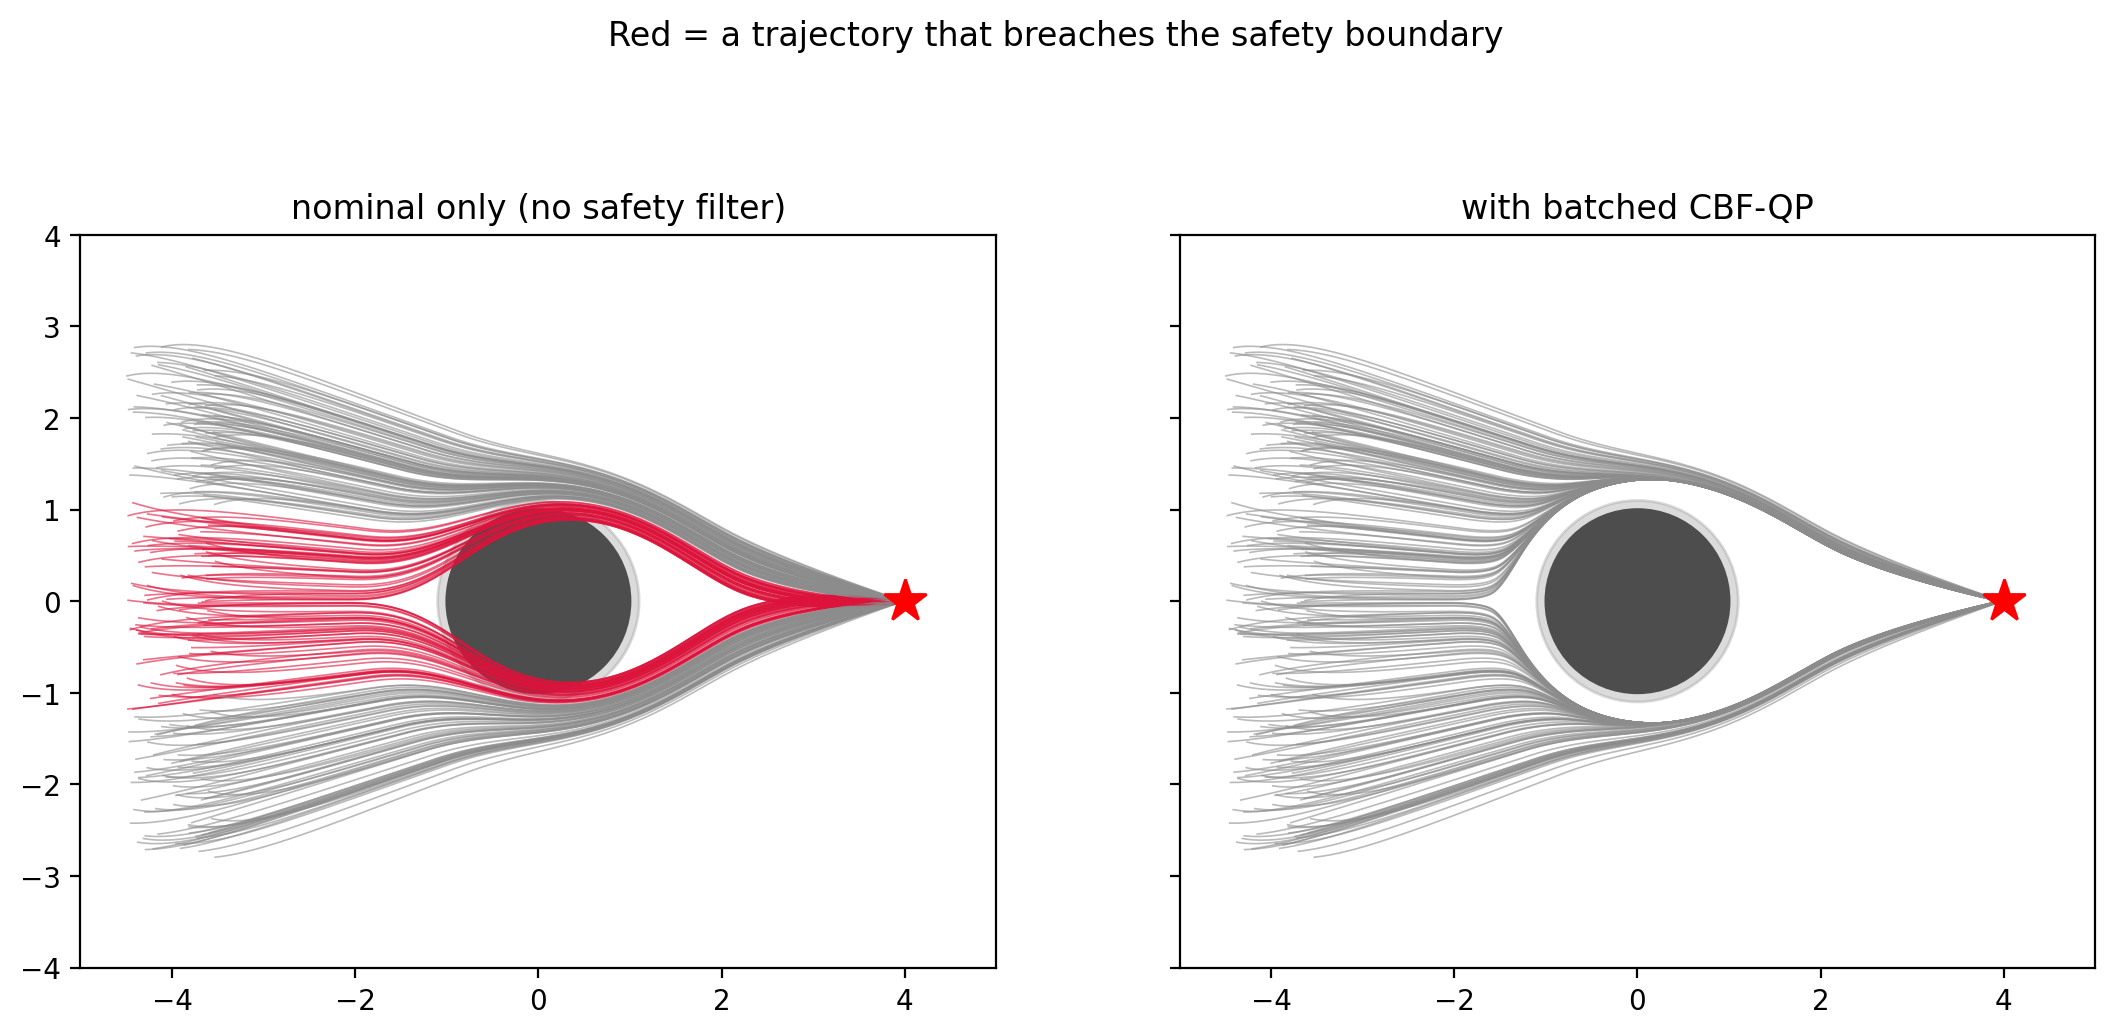

In [16]:
traj_no_h = traj_no.get()
fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=True, sharey=True)
for ax, data, title in [(axes[0], traj_no_h, "nominal only (no safety filter)"),
                        (axes[1], traj_h,    "with batched CBF-QP")]:
    ax.add_patch(plt.Circle((0, 0), d_min, color="0.6", alpha=0.35))
    ax.add_patch(plt.Circle((0, 0), r_obs, color="0.3"))
    for i in idx:
        unsafe = float(np.min(np.sqrt(data[:, i, 0] ** 2 + data[:, i, 1] ** 2) - d_min)) < 0
        ax.plot(data[:, i, 0], data[:, i, 1], lw=0.6, alpha=0.6,
                color="crimson" if unsafe else "0.55")
    ax.plot(float(goal[0]), float(goal[1]), "r*", ms=16)
    ax.set_aspect("equal"); ax.set_title(title)
axes[0].set_xlim(-5, 5); axes[0].set_ylim(-4, 4)
plt.suptitle("Red = a trajectory that breaches the safety boundary"); plt.show()

## Scaling: how throughput grows with the batch

The simulation re-solves the whole batch every control cycle, so the cost that matters is a
**single batched solve** as the batch grows. cuPIQP records the interior-point iteration as a CUDA
graph and replays it, so repeated solves are cheap and the per-QP cost keeps dropping until the GPU
saturates. Below we sweep the batch size and plot both the solve time and the resulting throughput.

   batch B   ms / solve           QPs / s
         1        4.826               207
        32        5.331             6,002
       128        5.395            23,725
       512        5.573            91,871
     2,048        6.613           309,684
     8,192       12.309           665,502
    32,768       39.385           831,996


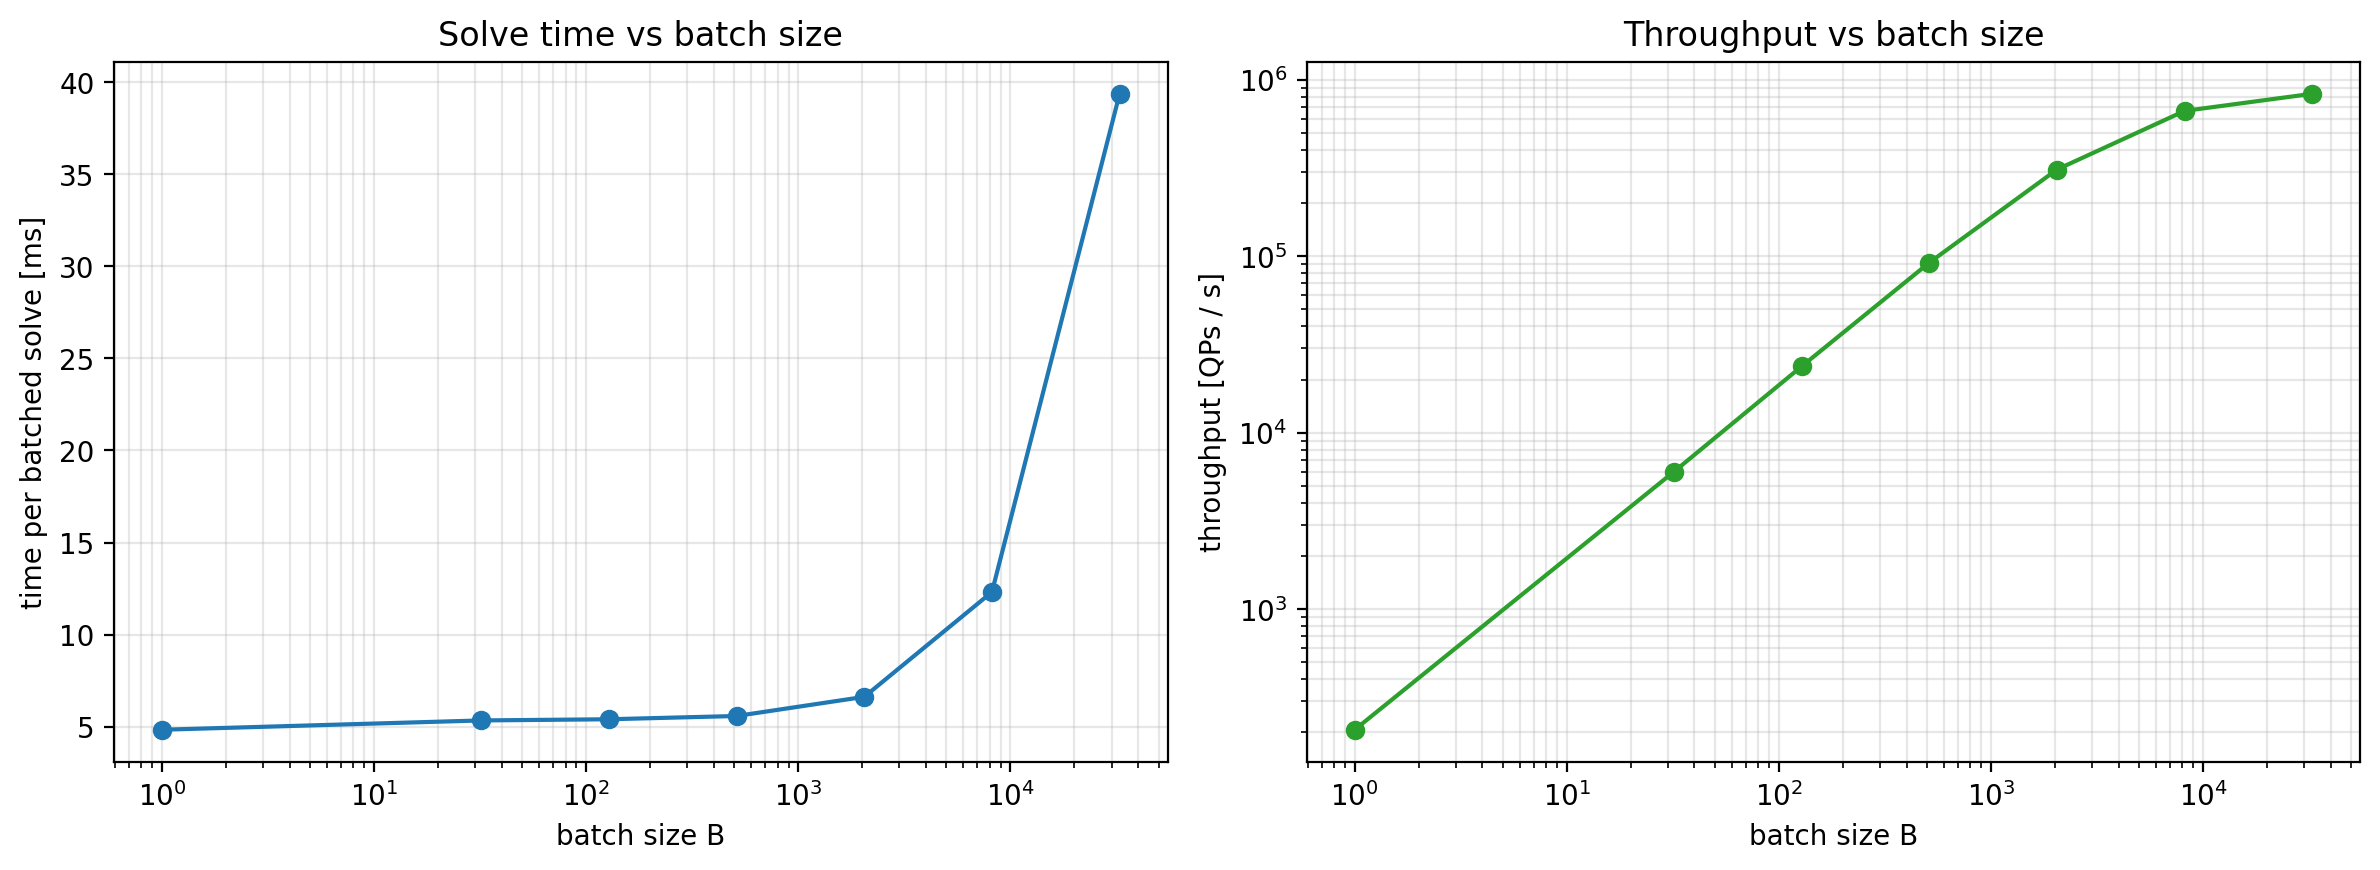

In [ ]:
batch_sizes = [1, 32, 128, 512, 2048, 8192, 32768]
solve_ms, throughput = [], []

print(f"{'batch B':>10}  {'ms / solve':>11}  {'QPs / s':>16}")
for BB in batch_sizes:
    Xb  = initial_states(BB)
    Pb  = cp.broadcast_to(cp.eye(2, dtype=float_dtype), (BB, 2, 2)).copy()
    xlb = cp.broadcast_to(cp.array([-v_max, -w_max], dtype=float_dtype), (BB, 2)).copy()
    xub = cp.broadcast_to(cp.array([ v_max,  w_max], dtype=float_dtype), (BB, 2)).copy()
    ur = nominal_policy(Xb); hb, ab = barrier_and_grad(Xb)
    sv = DenseSolver(dtype="float32")
    sv.setup(P=Pb, c=-ur, G=ab.reshape(BB, 1, 2), h_l=(-alpha * hb).reshape(BB, 1),
             h_u=None, x_l=xlb, x_u=xub)
    sv.solve()  # warm up: records the CUDA graph
    reps = 30
    cp.cuda.Stream.null.synchronize(); t0 = time.time()
    for _ in range(reps):
        sv.solve()
    cp.cuda.Stream.null.synchronize(); ms = (time.time() - t0) / reps * 1e3
    solve_ms.append(ms); throughput.append(BB / ms * 1e3)
    print(f"{BB:>10,}  {ms:>11.3f}  {BB / ms * 1e3:>16,.0f}")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.5))
axL.semilogx(batch_sizes, solve_ms, "o-", color="C0")
axL.set_xlabel("batch size B")
axL.set_ylabel("time per batched solve [ms]")
axL.set_title("Solve time vs batch size")
axL.grid(True, which="both", alpha=0.3)

axR.loglog(batch_sizes, throughput, "o-", color="C2")
axR.set_xlabel("batch size B")
axR.set_ylabel("throughput [QPs / s]")
axR.set_title("Throughput vs batch size")
axR.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## Why this example matters

The exact same optimization structure -- a tiny QP that projects a nominal control onto a safe set
-- appears throughout robotics:

- **Safe RL safety layers** -- a CBF-QP wraps a learned policy so exploration stays safe.
- **Multi-agent navigation** -- every agent solves a per-cycle QP for collision avoidance.
- **Robot collision avoidance** -- manipulators and mobile robots filter commands against obstacles.
- **Large-scale simulation** -- training and evaluation environments step thousands of agents at once.

Although each QP is extremely small, modern robotics workloads may require solving thousands or
tens of thousands of such QPs simultaneously. This is precisely the regime targeted by cuPIQP.